# **Chhattisgarh Power Consumption Forecasting**

![Chhattisgarh Power Consumption Forecasting Banner](cg_power_banner.png)

This notebook explores electricity consumption patterns across Chhattisgarh at the **consumer, division, and monthly** level. The analysis focuses on identifying long-term trends, seasonal variations, and differences in electricity usage influenced by industrial activity, urbanization, and temperature.

The data is aggregated at the monthly level to enable time series analysis. Key insights such as seasonal demand patterns, division-wise consumption differences, and correlations with external factors are examined.

Using **Prophet**, the notebook builds a forecasting model to estimate future electricity demand while capturing trend growth and seasonality. The goal is to provide an interpretable view of electricity consumption and support future energy planning.

In [61]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series forecasting
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Settings
pd.set_option('display.max_columns', None)

# **Data Loading**

The dataset is loaded from GitHub using a raw CSV URL.

In [62]:
url="https://raw.githubusercontent.com/RKYEngineering/chhattisgarh-electricity-demand-forecasting/refs/heads/main/data/chhattisgarh-electricity-consumption-2012-2022.csv"
df=pd.read_csv(url)

In [63]:
df.head(5)

,Division,Area,Consumer Name,Consumer Category,DISCOM,Meter Number,Meter Type,Revenue Month,Service Start Date,Service End Date,Consumption (KWH),Consumption (KW),KWH Charges,KW Charges,Fixed Charges,Other Charges,Current Charges,Tariff Category,Temperature,Industrial Index,Urbanization Level
0,Raipur Division,Industrial Area,Consumer_4582,Commercial,CSPDCL,77827638,Digital Meter,2012-04,2012-04-12,2012-05-12,38632,1752.03,307613.91,501679.13,1976.23,257.21,811526.48,HT Industrial,42.415505,1.2,0.80
1,Surguja Division,Urban Sector,Consumer_6574,Domestic,CSPDCL,30868105,Smart Meter,2014-03,2014-03-25,2014-04-24,7007,241.75,42832.13,88800.84,2397.02,487.39,134517.37,Commercial,27.160196,0.8,0.45
2,Raipur Division,Industrial Area,Consumer_5803,Domestic,CSPDCL,87490893,Smart Meter,2013-01,2013-01-14,2013-02-13,22261,880.21,115174.00,233129.09,812.07,1860.13,350975.29,HT Industrial,13.799273,1.2,0.80
3,Raipur Division,Commercial Complex,Consumer_6820,Commercial,CSPDCL,99949389,AMR,2019-06,2019-06-01,2019-07-01,56337,2284.94,304445.47,501529.25,2089.21,856.70,808920.63,HT Industrial,37.278983,1.2,0.80
4,Surguja Division,Industrial Area,Consumer_4752,Industrial,CSPDCL,52339391,AMR,2019-02,2019-02-13,2019-03-15,8183,296.60,73304.08,91945.98,1892.37,1432.31,168574.74,Commercial,21.711386,0.8,0.45


In [64]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Division            50000 non-null  object 
 1   Area                50000 non-null  object 
 2   Consumer Name       50000 non-null  object 
 3   Consumer Category   50000 non-null  object 
 4   DISCOM              50000 non-null  object 
 5   Meter Number        50000 non-null  int64  
 6   Meter Type          50000 non-null  object 
 7   Revenue Month       50000 non-null  object 
 8   Service Start Date  50000 non-null  object 
 9   Service End Date    50000 non-null  object 
 10  Consumption (KWH)   50000 non-null  int64  
 11  Consumption (KW)    50000 non-null  float64
 12  KWH Charges         50000 non-null  float64
 13  KW Charges          50000 non-null  float64
 14  Fixed Charges       50000 non-null  float64
 15  Other Charges       50000 non-null  float64
 16  Curr

# **Dataset Overview**

The dataset contains 50,000 records of electricity consumption across divisions in Chhattisgarh.

Includes categorical, numerical, and time-based features
No missing values, indicating good data quality
Suitable for analysis and time series forecasting

In [65]:
df['Revenue Month'] = pd.to_datetime(df['Revenue Month'])
df['Service Start Date'] = pd.to_datetime(df['Service Start Date'])
df['Service End Date'] = pd.to_datetime(df['Service End Date'])

# **Date Conversion**

The date columns were converted to datetime format to enable time-based analysis such as trend identification, seasonality detection, and forecasting.

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Division            50000 non-null  object        
 1   Area                50000 non-null  object        
 2   Consumer Name       50000 non-null  object        
 3   Consumer Category   50000 non-null  object        
 4   DISCOM              50000 non-null  object        
 5   Meter Number        50000 non-null  int64         
 6   Meter Type          50000 non-null  object        
 7   Revenue Month       50000 non-null  datetime64[ns]
 8   Service Start Date  50000 non-null  datetime64[ns]
 9   Service End Date    50000 non-null  datetime64[ns]
 10  Consumption (KWH)   50000 non-null  int64         
 11  Consumption (KW)    50000 non-null  float64       
 12  KWH Charges         50000 non-null  float64       
 13  KW Charges          50000 non-null  float64   

# **Data Aggregation**

The data is aggregated at the monthly level to create a time series dataset.

In [67]:
dfm = df[['Revenue Month', 'Consumption (KWH)']]

df_month = dfm.groupby('Revenue Month')['Consumption (KWH)'].sum().reset_index()

df_month.head()

,Revenue Month,Consumption (KWH)
0,2012-01-01,5581746
1,2012-02-01,7045779
2,2012-03-01,6040911
3,2012-04-01,7791071
4,2012-05-01,9478317


# **Aggregated Data Output**


The aggregated dataset shows total monthly electricity consumption over time. The values vary across months, indicating potential seasonal patterns. Further visualization is required to confirm trends and seasonality.

# **Trend Analysis**

The monthly electricity consumption is visualized to identify long-term trends and patterns.

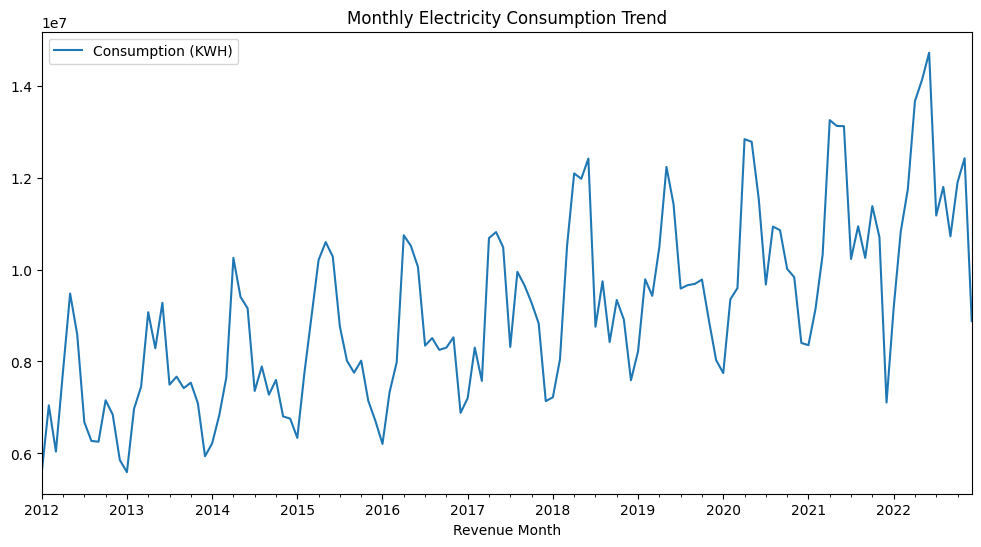

In [68]:
import matplotlib.pyplot as plt

df_month.plot(
    x='Revenue Month',
    y='Consumption (KWH)',
    figsize=(12,6),
    title='Monthly Electricity Consumption Trend'
)

plt.show()

# **Monthly Consumption Trend**

The time series plot shows a clear upward trend in electricity consumption from 2012 to 2022, indicating increasing demand over time.

A repeating pattern is observed across years, suggesting strong seasonality, with higher consumption during summer months and lower consumption during winter months.

Additionally, some fluctuations are visible, which may be due to variations in industrial activity or other external factors.

# **Seasonality Analysis**

Monthly averages are analyzed to identify recurring seasonal patterns.

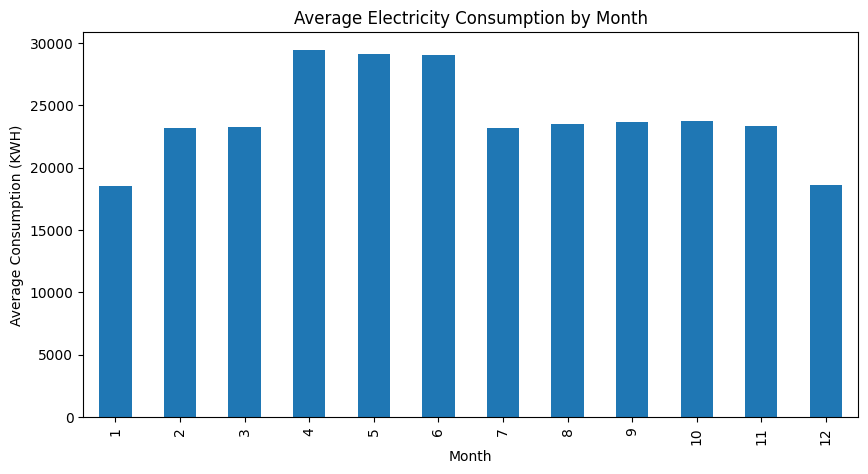

In [69]:
df['Month'] = df['Revenue Month'].dt.month

monthly_avg = df.groupby('Month')['Consumption (KWH)'].mean()

monthly_avg.plot(
    kind='bar',
    figsize=(10,5),
    title='Average Electricity Consumption by Month'
)

plt.xlabel('Month')
plt.ylabel('Average Consumption (KWH)')
plt.show()

# **Seasonality Analysis**

The monthly average consumption clearly demonstrates a strong seasonal pattern. Electricity consumption peaks during the summer months (April–June), reaching the highest levels, while it declines significantly during the winter months (December–January).

This pattern indicates increased electricity usage for cooling during hotter periods and reduced demand during colder months, confirming the presence of seasonality in the dataset.

# **Division-wise Analysis**

Electricity consumption is compared across divisions to identify regional differences.

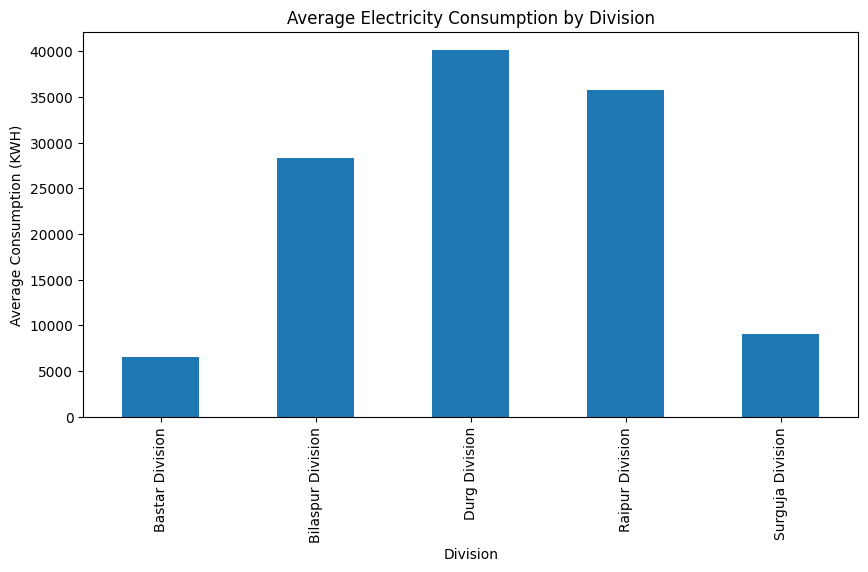

In [70]:
division_avg = df.groupby('Division')['Consumption (KWH)'].mean()

division_avg.plot(
    kind='bar',
    figsize=(10,5),
    title='Average Electricity Consumption by Division'
)

plt.xlabel('Division')
plt.ylabel('Average Consumption (KWH)')
plt.show()

# **Division-wise Analysis**

The division-wise analysis reveals significant variation in electricity consumption across regions. Durg Division shows the highest average consumption, followed by Raipur and Bilaspur divisions, indicating higher industrial activity and urbanization in these areas.

In contrast, Bastar and Surguja divisions exhibit significantly lower consumption levels, which can be attributed to their predominantly rural and forested regions with limited industrial development.

# **Correlation Analysis**

The relationship between consumption and external factors such as temperature and industrial activity is analyzed.

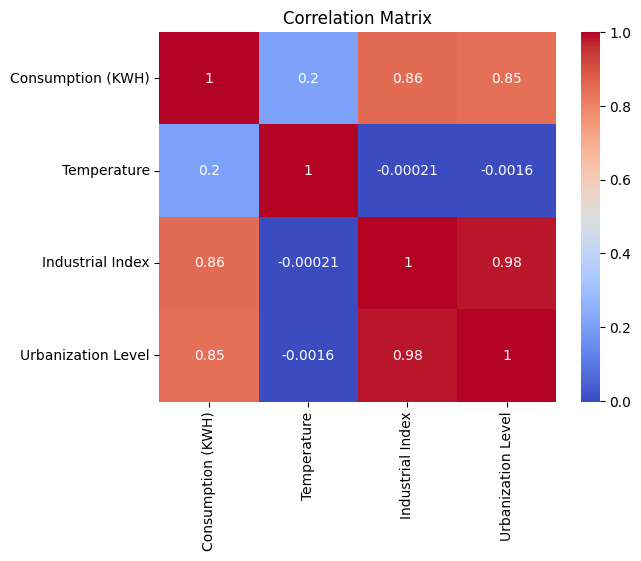

In [71]:
corr = df[['Consumption (KWH)', 'Temperature', 'Industrial Index', 'Urbanization Level']].corr()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

# **Correlation Analysis**

The correlation matrix reveals a strong positive relationship between electricity consumption and both industrial index (0.86) and urbanization level (0.85), indicating that regions with higher industrial activity and urban development consume more electricity.

Temperature shows a weaker positive correlation (0.20) with consumption, suggesting that while seasonal effects exist, other factors such as industrialization have a stronger impact on overall electricity demand.

Additionally, industrial index and urbanization level exhibit a very strong correlation (0.98), reflecting that highly industrialized regions are also more urbanized.

# **Outlier Detection**

A boxplot is used to identify extreme values in electricity consumption.

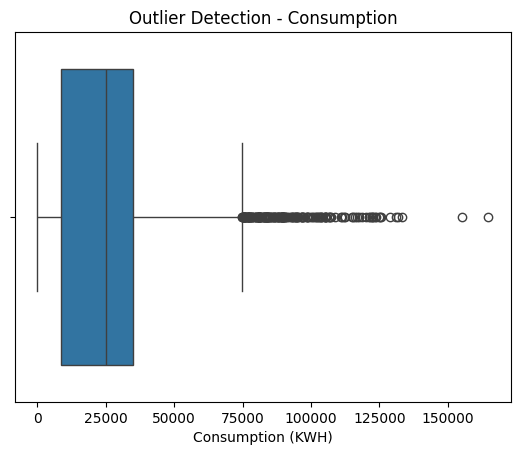

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Consumption (KWH)'])
plt.title('Outlier Detection - Consumption')
plt.show()

# **Outlier Analysis**

The boxplot shows that most electricity consumption values lie within a typical range, while several high-value outliers are present. The distribution is right-skewed, indicating occasional spikes in consumption.

These outliers likely represent periods of high industrial activity or peak demand. Since such variations are common in real-world electricity data, the outliers are retained for further analysis and forecasting.

In [73]:
df_prophet = df_month.rename(columns={
    'Revenue Month': 'ds',
    'Consumption (KWH)': 'y'
})

df_prophet.head()

,ds,y
0,2012-01-01,5581746
1,2012-02-01,7045779
2,2012-03-01,6040911
3,2012-04-01,7791071
4,2012-05-01,9478317


# **Data Preparation for Forecasting**

The dataset was prepared for time series forecasting by renaming columns to match Prophet’s requirements. The date column was renamed to "ds" and the target variable (electricity consumption) to "y".

In [74]:
from prophet import Prophet

model = Prophet()
model.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


# **Model Training**

A Prophet model was trained on the monthly electricity consumption data to capture trends and seasonal patterns for forecasting future demand.

# **Forecasting using Prophet**

A time series forecasting model is built using Prophet to predict future electricity demand.

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


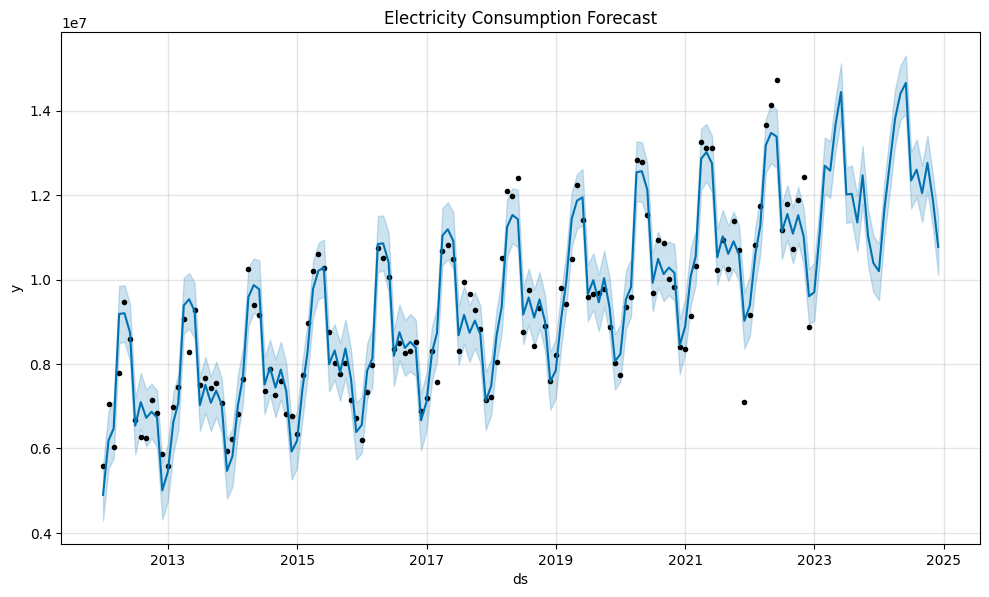

In [75]:
future = model.make_future_dataframe(periods=24, freq='M')

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

model.plot(forecast)
plt.title('Electricity Consumption Forecast')
plt.show()

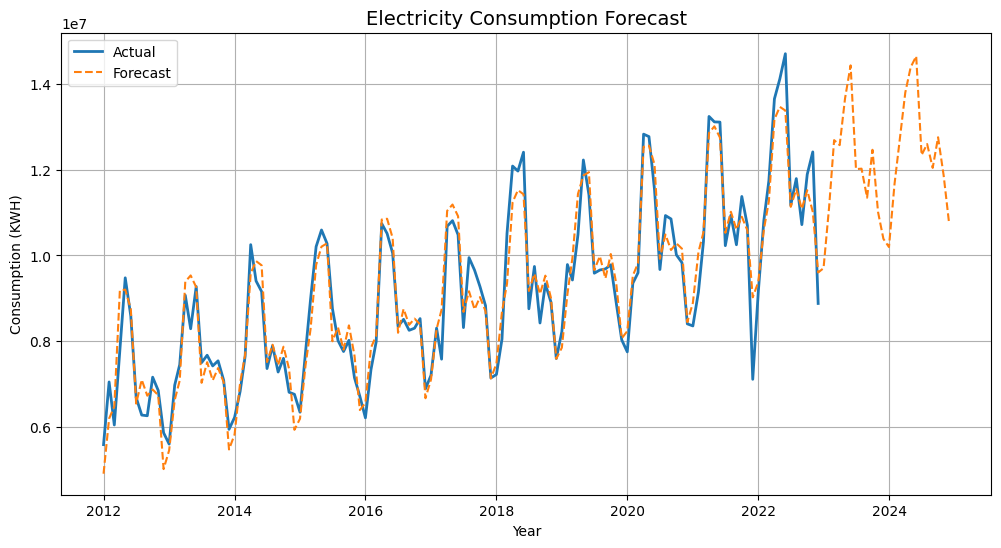

In [76]:
plt.figure(figsize=(12,6))

plt.plot(df_month['Revenue Month'], df_month['Consumption (KWH)'], label='Actual', linewidth=2)
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', linestyle='--')

plt.title('Electricity Consumption Forecast', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Consumption (KWH)')
plt.legend()
plt.grid()

plt.show()

# **Forecast Visualization Comparison**

The custom plot provides a simple comparison between actual and forecasted values, making it easy to understand trends. In contrast, the Prophet plot includes confidence intervals, offering additional insight into the uncertainty of predictions. This helps in better understanding the reliability of the forecast.

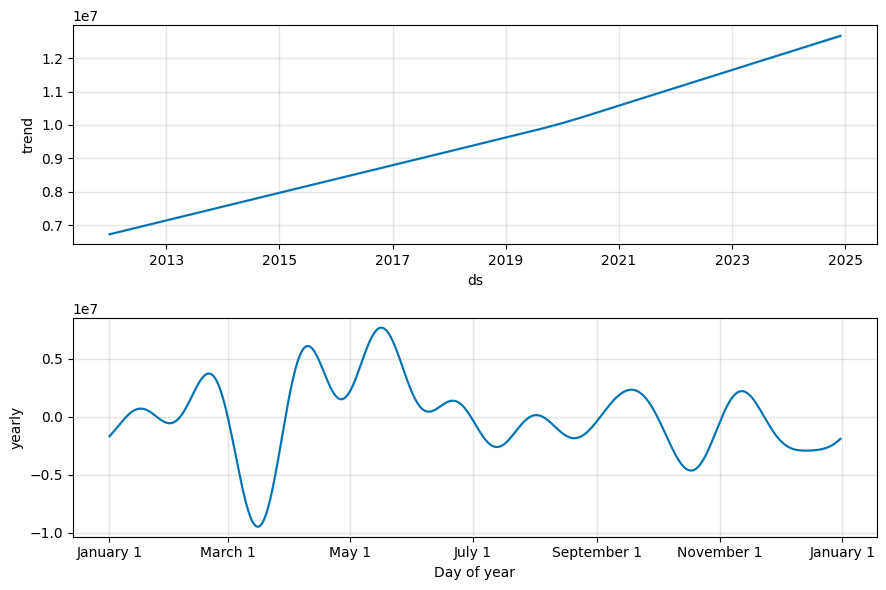

In [77]:
model.plot_components(forecast)
plt.show()

# **Forecasting Analysis**

The Prophet model successfully captures the increasing trend and seasonal patterns in electricity consumption. The forecast indicates a continued rise in demand, with recurring seasonal peaks during summer months.

This suggests that electricity demand is expected to grow in the future, highlighting the need for effective energy planning and resource management.

# **Model Evaluation**



In [78]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Merge actual and predicted
df_eval = df_prophet.merge(forecast[['ds', 'yhat']], on='ds')

# Calculate metrics
rmse = np.sqrt(mean_squared_error(df_eval['y'], df_eval['yhat']))
mae = mean_absolute_error(df_eval['y'], df_eval['yhat'])

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 526142.1670196495
MAE: 409622.89419351035


# **Model Evaluation**

The model was evaluated using RMSE and MAE. Although the error values are high, they are small compared to the overall consumption values (in millions).

This indicates that the model provides reasonably accurate predictions.

# **Conclusion**

This project analyzed electricity consumption patterns across divisions in Chhattisgarh using time series techniques. The analysis revealed a clear upward trend in electricity demand along with strong seasonal patterns, with higher consumption during summer months.

Division-wise analysis showed that industrial and urban regions have significantly higher consumption compared to rural areas. Correlation analysis further confirmed that industrial activity and urbanization are key drivers of electricity demand.

The Prophet model successfully captured both trend and seasonality, providing reliable forecasts for future consumption. The results highlight the importance of effective energy planning to meet increasing demand.